# Exploratory Data Analysis  
## Beatport Tracks + Spotify Audio Features

This notebook contains the exploratory data analysis of a large dataset of electronic music tracks combining Beatport metadata and Spotify audio features.

Objectives:

- Understand the structure of the dataset
- Explore distributions of audio features
- Identify relationships between musical characteristics
- Detect potential patterns in electronic music production

In [3]:
# Import core libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

pd.set_option('display.max_columns', None)

In [4]:
# Define path to raw dataset directory

data_path = "../data/raw/"

In [5]:
# Load Spotify audio features dataset

audio = pd.read_csv(data_path + "audio_features.csv")

In [6]:
# Preview the first rows to understand dataset structure

audio.head()

,isrc,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,updated_on
0,AD4X65752184,0.906000,0.650,296733,0.350,0.775,3,0.1140,-11.777,1,0.0284,110,4,0.336,2023-08-24 09:27:00
1,AEA0D1991170,0.000950,0.621,191989,0.639,0.820,7,0.5060,-9.258,1,0.0775,140,4,0.346,2023-08-24 09:30:04
2,AEA0Q2004008,0.031200,0.692,282904,0.980,0.866,9,0.0969,-9.952,1,0.0881,140,4,0.225,2023-08-24 09:30:04
3,AEA0Q2004009,0.000558,0.516,197904,0.924,0.434,5,0.1530,-13.564,0,0.2200,148,4,0.204,2023-08-24 09:30:04
4,AEA0Q2004010,0.009380,0.587,199471,0.910,0.804,0,0.5630,-10.552,1,0.0596,136,4,0.321,2023-08-24 09:30:04


In [7]:
# Check number of rows and columns

audio.shape

(4687104, 15)

In [8]:
# Inspect data types and missing values

audio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4687104 entries, 0 to 4687103
Data columns (total 15 columns):
 #   Column            Dtype  
---  ------            -----  
 0   isrc              object 
 1   acousticness      float64
 2   danceability      float64
 3   duration_ms       int64  
 4   energy            float64
 5   instrumentalness  float64
 6   key               int64  
 7   liveness          float64
 8   loudness          float64
 9   mode              int64  
 10  speechiness       float64
 11  tempo             int64  
 12  time_signature    int64  
 13  valence           float64
 14  updated_on        object 
dtypes: float64(8), int64(5), object(2)
memory usage: 536.4+ MB


In [9]:
# Summary statistics of numerical variables

audio.describe()

,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
count,4.687104e+06,4.687104e+06,4.687104e+06,4.687104e+06,4.687104e+06,4.687104e+06,4.687104e+06,4.687104e+06,4.687104e+06,4.687104e+06,4.687104e+06,4.687104e+06,4.687104e+06
mean,1.115222e-01,6.762825e-01,3.395846e+05,7.149000e-01,6.336123e-01,5.556958e+00,1.746018e-01,-9.215520e+00,5.422555e-01,8.774978e-02,1.268136e+02,3.959320e+00,3.957805e-01
std,2.241004e-01,1.573557e-01,1.909052e+05,2.097366e-01,3.432355e-01,3.690800e+00,1.629871e-01,4.168868e+00,4.982113e-01,8.655872e-02,2.113567e+01,3.182083e-01,2.555503e-01
min,0.000000e+00,0.000000e+00,1.000000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-6.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.820000e-04,5.980000e-01,2.453330e+05,5.840000e-01,3.840000e-01,2.000000e+00,8.390000e-02,-1.105900e+01,0.000000e+00,4.440000e-02,1.200000e+02,4.000000e+00,1.760000e-01
50%,9.170000e-03,7.130000e-01,3.411600e+05,7.500000e-01,8.180000e-01,6.000000e+00,1.100000e-01,-8.640000e+00,1.000000e+00,5.810000e-02,1.260000e+02,4.000000e+00,3.660000e-01
75%,8.500000e-02,7.970000e-01,4.135420e+05,8.860000e-01,8.890000e-01,9.000000e+00,1.910000e-01,-6.590000e+00,1.000000e+00,8.770000e-02,1.330000e+02,4.000000e+00,5.860000e-01
max,9.960000e-01,1.000000e+00,6.074945e+06,1.000000e+00,1.000000e+00,1.100000e+01,1.000000e+00,5.485000e+00,1.000000e+00,9.690000e-01,2.500000e+02,5.000000e+00,1.000000e+00


In [10]:
# Check missing values per column

audio.isnull().sum()

isrc                0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
updated_on          0
dtype: int64

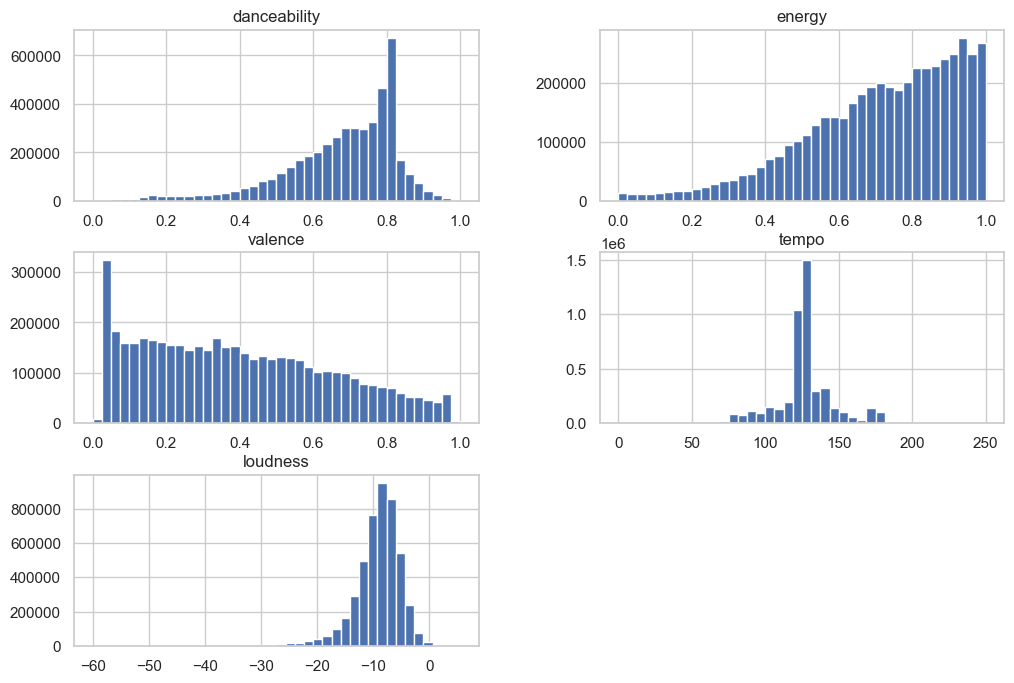

In [11]:
# Plot distribution of key audio features

features = [
    "danceability",
    "energy",
    "valence",
    "tempo",
    "loudness"
]

audio[features].hist(bins=40, figsize=(12,8))
plt.show()

## Distribution of Key Audio Features

The histograms above show the distribution of several core audio characteristics
for more than 4.6 million electronic music tracks.

Several patterns can already be observed:

- **Danceability** shows a strong concentration between 0.6 and 0.85, suggesting
  that most tracks in the dataset are highly suitable for dancing.

- **Energy** is strongly skewed toward higher values, which is consistent with
  the energetic nature of electronic music.

- **Valence** presents a wider distribution, indicating a mix of more positive
  and darker emotional tones across tracks.

- **Tempo** is concentrated around the 120–130 BPM range, which aligns with the
  typical tempo used in many electronic music genres such as house and techno.

- **Loudness** is centered around approximately -10 dB, reflecting common
  mastering levels used in modern electronic music production.

These initial observations confirm that the dataset captures typical
characteristics of contemporary electronic dance music.

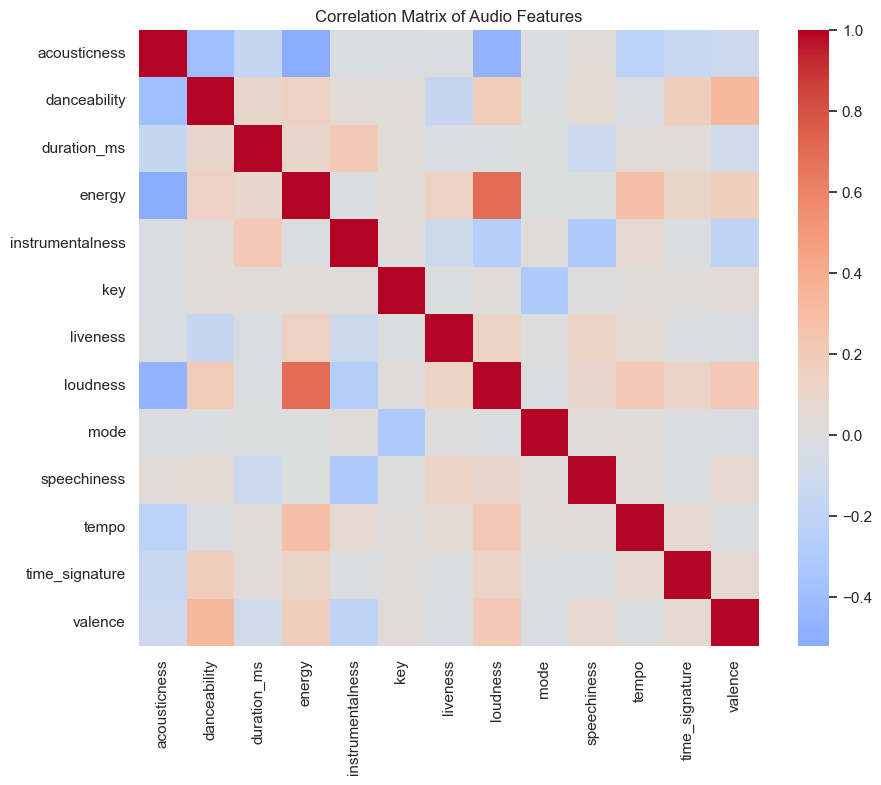

In [13]:
# Compute correlation matrix for numerical variables

corr_matrix = audio.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)

plt.title("Correlation Matrix of Audio Features")

plt.show()

## Correlation Analysis of Audio Features

The correlation matrix highlights several interesting relationships between
audio characteristics.

**Energy and Loudness**

A strong positive correlation can be observed between energy and loudness.
This relationship is expected, as more energetic tracks tend to be mastered
with higher perceived loudness levels.

**Acousticness and Energy**

A negative relationship appears between acousticness and energy. Tracks with
higher acoustic content generally contain fewer heavily processed electronic
elements, which often results in lower overall energy levels.

**Danceability and Valence**

A moderate positive relationship can be observed between danceability and
valence. Tracks that are more danceable tend to exhibit a slightly more
positive emotional character.

Overall, most variables show relatively low correlations, suggesting that the
audio features capture different aspects of musical characteristics.

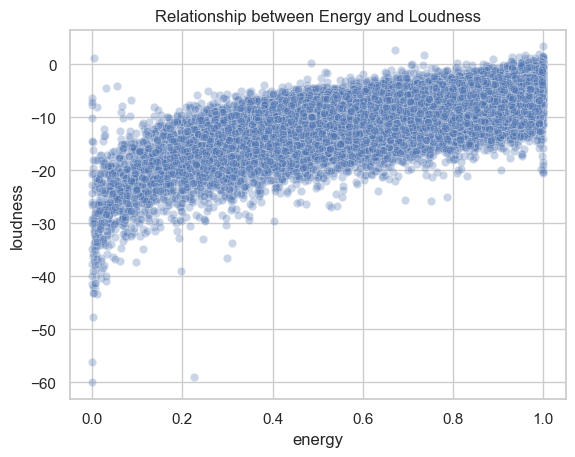

In [15]:
# Relationship between energy and loudness

sns.scatterplot(
    x="energy",
    y="loudness",
    data=audio.sample(50000),
    alpha=0.3
)

plt.title("Relationship between Energy and Loudness")

plt.show()

### Relationship between Energy and Loudness

The scatter plot reveals a clear positive relationship between **energy** and
**loudness**.

Tracks with higher energy levels tend to be mastered with higher loudness,
which is expected in modern music production. Energetic tracks typically
contain denser arrangements and stronger rhythmic elements, which are often
processed with compression and limiting during mastering.

At lower energy levels, the loudness values show much greater dispersion,
suggesting the presence of quieter or more dynamic tracks such as ambient or
experimental productions.

At higher energy levels, loudness values become more concentrated between
approximately -10 dB and -4 dB, which reflects typical mastering levels used
in contemporary electronic music.

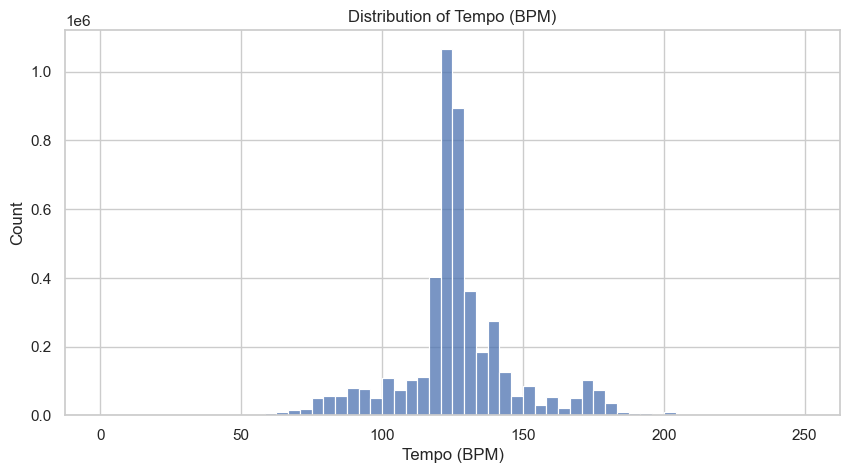

In [17]:
# Distribution of tempo (BPM)

plt.figure(figsize=(10,5))

sns.histplot(audio["tempo"], bins=60)

plt.title("Distribution of Tempo (BPM)")
plt.xlabel("Tempo (BPM)")
plt.ylabel("Count")

plt.show()

## Distribution of Tempo (BPM)

The tempo distribution reveals clear structural patterns in the dataset.

The majority of tracks are concentrated between **120 and 130 BPM**, which is
consistent with the typical tempo range of many electronic music genres such
as house, tech house and melodic techno.

A secondary concentration appears between **100 and 115 BPM**, which may
correspond to slower electronic styles such as downtempo or certain deep house
productions.

Higher tempo tracks also appear in the **160–180 BPM** range, which could be
associated with faster electronic genres such as drum & bass or hardcore.

A small number of observations close to **0 BPM** are also present, which may
indicate missing tempo detection or atypical musical structures.

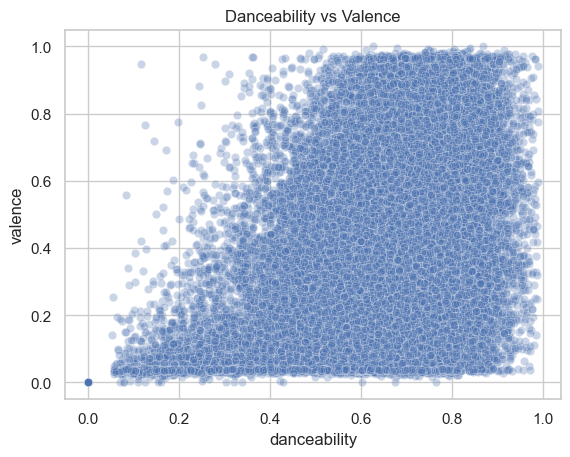

In [32]:
# Relationship between danceability and valence

sns.scatterplot(
    x="danceability",
    y="valence",
    data=audio.sample(50000),
    alpha=0.3
)

plt.title("Danceability vs Valence")

plt.show()

### Relationship between Danceability and Valence

The scatter plot shows the relationship between danceability and valence,
two important musical characteristics describing rhythmic suitability and
emotional tone.

A mild positive trend can be observed: tracks with higher danceability tend
to show slightly higher valence values. This suggests that music designed for
dancing often carries a somewhat more positive emotional character.

However, the relationship is far from deterministic. Even highly danceable
tracks can exhibit a wide range of emotional tones, from darker and more
atmospheric tracks to very uplifting productions.

This dispersion likely reflects the diversity of electronic music styles
represented in the dataset.